# Baseline-моделирование интентов русскоязычных диалогов

**Цель ноутбука.** Реализовать baseline-этап ML-исследования для задачи многоклассовой классификации интента русскоязычного диалога (`primaryintent`) в рамках магистерской диссертации «Семантический анализ русскоязычных диалогов для задачи распознавания намерений с улучшением на базе предобученных моделей».

**Что делает ноутбук:**

- загружает размеченный CSV с Google Drive (если `df` не задан в окружении);
- нормализует имена колонок (`primary_intent` → `primaryintent`, `dialog_id` → `dialogid`, `is_ambiguous` → `isambiguous`);
- выполняет стратифицированное разбиение на train/val/test (70/15/15) с устойчивостью к редким классам;
- реализует два baseline-подхода: TF-IDF + линейный классификатор и fine-tuning русскоязычного трансформера;
- считает метрики (accuracy, macro-F1, weighted-F1), строит confusion matrix и сравнивает сценарии `full` / `clean`.

Ноутбук рассчитан на запуск в Google Colab, является самостоятельным и воспроизводимым. По умолчанию выполняется TF-IDF baseline; fine-tuning трансформера управляется флагом `RUN_TRANSFORMER` (по умолчанию `False`) для предотвращения случайных длинных запусков.

## Постановка задачи и данные

**Постановка задачи.** Многоклассовая классификация интента всего диалога: по входу — русскоязычный диалог (`dialogue`), на выходе — один из 15 интентов (`primaryintent`). По итогам sanity-check (см. `03_annotation_sanity_check.ipynb`):

- разметка `primaryintent` полная (нет пропусков);
- классы сильно несбалансированы — это нужно учитывать при разбиении, обучении и метриках;
- часть диалогов помечена как неоднозначные (`isambiguous == 1`) — отдельный сценарий `clean`.

**Замечание по именам колонок.** В исходном CSV используются имена с подчёркиванием (`dialog_id`, `primary_intent`, `is_ambiguous`). Для совместимости с постановкой задачи в ноутбуке выполняется нормализация к именам без подчёркивания: `dialogid`, `primaryintent`, `isambiguous`. Если `df` уже определён в окружении, ноутбук использует его и только нормализует имена колонок.

In [1]:
# Установка зависимостей при необходимости. В Colab transformers/datasets/accelerate
# обычно отсутствуют по умолчанию. Раскомментируйте при первом запуске.
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00


In [2]:
import os
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
# Пути к данным и результатам на Google Drive.
BASE_DIR = "/content/drive/MyDrive/russian-dialogue-intent-thesis"
DATA_DIR = f"{BASE_DIR}/data"
ANNO_DIR = f"{DATA_DIR}/annotation"
RESULTS_DIR = f"{BASE_DIR}/results"
TABLES_DIR = f"{RESULTS_DIR}/tables"
FIGURES_DIR = f"{RESULTS_DIR}/figures"

ANNOTATED_CSV = f"{ANNO_DIR}/dialogue_intent_annotation_1246_v1_annotated.csv"

In [4]:
# Загрузка размеченного CSV с Google Drive, если df ещё не определён в окружении.
if "df" not in globals():
    try:
        from google.colab import drive  # type: ignore
        drive.mount("/content/drive")
    except Exception as exc:
        print(f"google.colab.drive недоступен (вероятно, не Colab): {exc}")

    for d in (TABLES_DIR, FIGURES_DIR):
        os.makedirs(d, exist_ok=True)

    df = pd.read_csv(ANNOTATED_CSV)
    print(f"Загружено из CSV: {ANNOTATED_CSV}")
else:
    print("Используется уже определённый в окружении DataFrame df.")

Mounted at /content/drive
Загружено из CSV: /content/drive/MyDrive/russian-dialogue-intent-thesis/data/annotation/dialogue_intent_annotation_1246_v1_annotated.csv


In [5]:
# Нормализация имён колонок к именам без подчёркивания: dialogid, primaryintent, isambiguous.
RENAME_MAP = {
    "dialog_id": "dialogid",
    "primary_intent": "primaryintent",
    "is_ambiguous": "isambiguous",
}
for src, dst in RENAME_MAP.items():
    if src in df.columns and dst not in df.columns:
        df = df.rename(columns={src: dst})

REQUIRED_COLS = ["dialogid", "dialogue", "primaryintent", "isambiguous"]
missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    raise ValueError(
        f"В df отсутствуют необходимые колонки: {missing}. Доступные: {list(df.columns)}"
    )

df["isambiguous"] = df["isambiguous"].fillna(0).astype(int)
print("Колонки после нормализации:", list(df.columns))

Колонки после нормализации: ['dialogid', 'split', 'dialogue', 'summary', 'n_utterances', 'dialogue_words', 'summary_words', 'primaryintent', 'secondary_intent', 'isambiguous', 'annotation_notes', 'annotator', 'label_version']


In [6]:
print("Размер df:", df.shape)
print("Число уникальных primaryintent:", df["primaryintent"].nunique())
df[["dialogid", "primaryintent", "isambiguous"]].head()

Размер df: (1246, 13)
Число уникальных primaryintent: 15


,dialogid,primaryintent,isambiguous
0,train_6,финансовый_вопрос,0
1,train_9,интервью_или_собеседование,0
2,train_18,бытовое_обсуждение,0
3,train_27,интервью_или_собеседование,0
4,train_35,обсуждение_досуга,0


In [7]:
# Распределение классов и доля неоднозначных диалогов.
print("primaryintent value_counts:")
print(df["primaryintent"].value_counts())
print()
print("isambiguous value_counts:")
print(df["isambiguous"].value_counts())

primaryintent value_counts:
primaryintent
личное_общение                     248
обсуждение_работы_или_учебы        143
обсуждение_путешествия             117
покупка_или_заказ                  102
совет_или_рекомендация              91
обсуждение_досуга                   87
бытовое_обсуждение                  66
сервисное_обращение                 63
жалоба_или_проблема                 61
интервью_или_собеседование          50
обсуждение_здоровья                 48
запрос_информации                   47
финансовый_вопрос                   45
просьба_о_помощи                    43
договоренность_или_планирование     35
Name: count, dtype: int64

isambiguous value_counts:
isambiguous
0    931
1    315
Name: count, dtype: int64


## Разбиение на выборки (train/val/test)

Используется стратифицированное разбиение по `primaryintent` в пропорции 70/15/15 (train/val/test). Рассматриваются два сценария:

- **full** — все размеченные диалоги (включая `isambiguous == 1`);
- **clean** — только однозначные диалоги (`isambiguous == 0`).

**Caveat по редким классам.** Стратифицированный split требует, чтобы в каждом классе было достаточно примеров для попадания во все три выборки. В нашем датасете часть классов может содержать <10 примеров. Реализуем устойчивый split: редкие классы (с числом примеров < `min_per_class`, по умолчанию 3) детерминированно отправляем целиком в train с предупреждением, а оставшиеся стратифицируем через `StratifiedShuffleSplit`. Так ноутбук не падает на редких классах и не теряет данные.

In [8]:
def make_splits(df, label_col, test_size=0.15, val_size=0.15, random_state=42, min_per_class=3):
    """Стратифицированный split с устойчивым поведением для редких классов.

    Возвращает dict с ключами train_idx, val_idx, test_idx — позиционные индексы
    относительно переданного df (предполагается, что индекс уже сброшен).
    """
    df = df.reset_index(drop=True)
    counts = df[label_col].value_counts()
    rare_classes = counts[counts < min_per_class].index.tolist()
    if rare_classes:
        warnings.warn(
            f"Классы с числом примеров < {min_per_class} помещены целиком в train: "
            f"{rare_classes}",
            stacklevel=2,
        )

    rare_mask = df[label_col].isin(rare_classes)
    rare_idx = df.index[rare_mask].to_numpy()
    main_df = df.loc[~rare_mask]
    main_idx = main_df.index.to_numpy()
    y_main = main_df[label_col].to_numpy()

    # Сначала отделяем test
    sss_test = StratifiedShuffleSplit(
        n_splits=1, test_size=test_size, random_state=random_state
    )
    trainval_pos, test_pos = next(sss_test.split(main_idx, y_main))
    test_idx = main_idx[test_pos]
    trainval_idx = main_idx[trainval_pos]
    y_trainval = y_main[trainval_pos]

    # Затем отделяем val от оставшегося train+val.
    # Доля val относительно train+val: val_size / (1 - test_size).
    val_fraction = val_size / (1.0 - test_size)
    sss_val = StratifiedShuffleSplit(
        n_splits=1, test_size=val_fraction, random_state=random_state
    )
    train_pos, val_pos = next(sss_val.split(trainval_idx, y_trainval))
    train_idx = trainval_idx[train_pos]
    val_idx = trainval_idx[val_pos]

    # Редкие классы — детерминированно в train.
    train_idx = np.concatenate([train_idx, rare_idx])
    rng = np.random.default_rng(random_state)
    rng.shuffle(train_idx)

    return {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    }

In [9]:
# Сценарий full — весь df.
df_full = df.reset_index(drop=True)
splits_full = make_splits(df_full, label_col="primaryintent", random_state=SEED)

# Сценарий clean — только однозначные диалоги.
df_clean = df[df["isambiguous"] == 0].reset_index(drop=True)
splits_clean = make_splits(df_clean, label_col="primaryintent", random_state=SEED)

def report_splits(name, df_scenario, splits):
    print(f"=== Сценарий: {name} ===")
    print(f"Размер сценария: {len(df_scenario)}")
    for key in ("train_idx", "val_idx", "test_idx"):
        idx = splits[key]
        sub = df_scenario.loc[idx]
        print(f"\n[{name}/{key}] size = {len(idx)}")
        print(sub["primaryintent"].value_counts())
    print()

report_splits("full", df_full, splits_full)
report_splits("clean", df_clean, splits_clean)

=== Сценарий: full ===
Размер сценария: 1246

[full/train_idx] size = 872
primaryintent
личное_общение                     174
обсуждение_работы_или_учебы        100
обсуждение_путешествия              81
покупка_или_заказ                   72
совет_или_рекомендация              63
обсуждение_досуга                   61
бытовое_обсуждение                  46
сервисное_обращение                 44
жалоба_или_проблема                 43
интервью_или_собеседование          35
обсуждение_здоровья                 34
запрос_информации                   33
финансовый_вопрос                   31
просьба_о_помощи                    30
договоренность_или_планирование     25
Name: count, dtype: int64

[full/val_idx] size = 187
primaryintent
личное_общение                     37
обсуждение_работы_или_учебы        21
обсуждение_путешествия             18
покупка_или_заказ                  15
совет_или_рекомендация             14
обсуждение_досуга                  13
сервисное_обращение             

## Baseline-модели

Реализуем два baseline:

1. **TF-IDF + линейный классификатор** (`LogisticRegression` с `class_weight='balanced'`). Простой, быстрый, интерпретируемый baseline; учитываем дисбаланс через веса классов.
2. **Fine-tuning русскоязычного трансформера** (`cointegrated/rubert-tiny2` по умолчанию, опция `DeepPavlov/rubert-base-cased` для более сильной, но более тяжёлой модели). Запуск управляется флагом `RUN_TRANSFORMER`, чтобы не запускать fine-tuning при сборке/просмотре ноутбука.

### Baseline 1. TF-IDF + линейный классификатор

In [10]:
def build_tfidf_features(texts_train, texts_val, texts_test, max_features=30000):
    """Строит TF-IDF признаки (1-2-граммы) на train и применяет к val/test."""
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=max_features,
        min_df=2,
        max_df=0.9,
    )
    X_train = vectorizer.fit_transform(texts_train)
    X_val = vectorizer.transform(texts_val)
    X_test = vectorizer.transform(texts_test)
    return vectorizer, X_train, X_val, X_test

In [11]:
def train_linear_baseline(
    X_train, y_train, X_val, y_val,
    C_grid=(0.5, 1.0, 2.0), random_state=42,
):
    """Обучает LogisticRegression с class_weight='balanced' и подбирает C по macro-F1 на val."""
    best_model = None
    best_score = -np.inf
    best_C = None
    for C in C_grid:
        model = LogisticRegression(
            C=C,
            max_iter=500,
            class_weight="balanced",
            n_jobs=-1,
            random_state=random_state,
        )
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        score = f1_score(y_val, val_pred, average="macro")
        print(f"  C={C}: val macro-F1 = {score:.4f}")
        if score > best_score:
            best_score = score
            best_model = model
            best_C = C
    print(f"  Лучший C = {best_C} (val macro-F1 = {best_score:.4f})")
    return best_model, best_C

### Baseline 2. Fine-tuning трансформера (опционально)

Для борьбы с дисбалансом классов (`личное_общение` доминирует) обе baseline-модели используют веса классов:

- **TF-IDF + LogisticRegression**: параметр `class_weight='balanced'` в `LogisticRegression`.
- **Трансформер**: кастомный `WeightedTrainer` переопределяет `compute_loss`, подставляя в `torch.nn.CrossEntropyLoss(weight=class_weights)` веса, рассчитанные по обратной частоте классов на train. Это снижает риск коллапса в мажоритарный класс (ранее macro-F1 был ~0.022 из-за того, что loss не учитывал дисбаланс).


In [12]:
# Управляющие флаги для трансформер-baseline.
# RUN_TRANSFORMER оставлен False по умолчанию, чтобы избежать случайного запуска
# дорогого обучения. Установите True, чтобы запустить fine-tuning.
RUN_TRANSFORMER = True
MODEL_NAME = "DeepPavlov/rubert-base-cased"
MAX_LENGTH = 256
BATCH_SIZE = 8
NUM_EPOCHS = 5
LEARNING_RATE = 3e-5


In [13]:
def prepare_transformer_data(df_scenario, splits, label_col="primaryintent", text_col="dialogue"):
    """Готовит HuggingFace Dataset'ы для train/val/test и возвращает mapping label2id/id2label."""
    from datasets import Dataset

    labels_sorted = sorted(df_scenario[label_col].unique().tolist())
    label2id = {lab: i for i, lab in enumerate(labels_sorted)}
    id2label = {i: lab for lab, i in label2id.items()}

    def to_ds(idx):
        sub = df_scenario.loc[idx, [text_col, label_col]].copy()
        sub = sub.rename(columns={text_col: "text"})
        sub["label"] = sub[label_col].map(label2id)
        return Dataset.from_pandas(sub[["text", "label"]].reset_index(drop=True))

    return {
        "train": to_ds(splits["train_idx"]),
        "val": to_ds(splits["val_idx"]),
        "test": to_ds(splits["test_idx"]),
        "label2id": label2id,
        "id2label": id2label,
    }

In [14]:
def train_transformer_baseline(
    data, model_name=None, max_length=None,
    batch_size=None, num_epochs=None, learning_rate=None,
    output_dir="/content/transformer_baseline", seed=SEED,
):
    """Fine-tune русскоязычного трансформера на train, валидация на val. Возвращает (trainer, tokenizer).

    Использует кастомный WeightedTrainer, который применяет веса классов
    (рассчитанные по train) в CrossEntropyLoss для борьбы с дисбалансом классов.
    Иначе трансформер схлопывается в мажоритарный класс `личное_общение`
    (наблюдался macro-F1 ~0.022).

    Если после weighted-loss качество всё ещё низкое, попробуйте увеличить
    NUM_EPOCHS до 5 и LEARNING_RATE до 3e-5 или 5e-5 для rubert-tiny2.
    """
    import inspect

    import numpy as np
    import pandas as pd
    import torch
    from sklearn.utils.class_weight import compute_class_weight
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        TrainingArguments,
        Trainer,
        DataCollatorWithPadding,
    )

    model_name = model_name or MODEL_NAME
    max_length = max_length or MAX_LENGTH
    batch_size = batch_size or BATCH_SIZE
    num_epochs = num_epochs or NUM_EPOCHS
    learning_rate = learning_rate or LEARNING_RATE

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, max_length=max_length)

    train_ds = data["train"].map(tokenize, batched=True)
    val_ds = data["val"].map(tokenize, batched=True)

    num_labels = len(data["label2id"])
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=data["id2label"],
        label2id=data["label2id"],
    )

    # === Веса классов по train (только!) для CrossEntropyLoss. ===
    train_labels = np.asarray(data["train"]["label"])
    classes = np.arange(num_labels)
    class_weights_np = compute_class_weight(
        class_weight="balanced", classes=classes, y=train_labels
    )
    class_weights = torch.tensor(class_weights_np, dtype=torch.float)

    # Диагностика: распределение меток в train и рассчитанные веса классов.
    id2label = data["id2label"]
    counts = pd.Series(train_labels).value_counts().reindex(classes, fill_value=0)
    diag = pd.DataFrame({
        "label_id": classes,
        "label": [id2label[i] for i in classes],
        "count": counts.values,
        "class_weight": np.round(class_weights_np, 4),
    }).sort_values("count", ascending=False).reset_index(drop=True)
    print("Распределение классов в train и веса для CrossEntropyLoss:")
    try:
        from IPython.display import display
        display(diag)
    except Exception:
        print(diag.to_string(index=False))

    # Совместимость с разными версиями transformers:
    # - старые версии (<=4.x ранние) ждут evaluation_strategy;
    # - новые версии (4.46+) переименовали аргумент в eval_strategy и удалили старое имя,
    #   из-за чего возникает TypeError: unexpected keyword argument 'evaluation_strategy'.
    # Поэтому собираем kwargs динамически по сигнатуре TrainingArguments.__init__.
    ta_params = inspect.signature(TrainingArguments.__init__).parameters
    training_args_kwargs = dict(
        output_dir=output_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=learning_rate,
        logging_steps=50,
        seed=seed,
        report_to="none",
    )
    if "eval_strategy" in ta_params:
        training_args_kwargs["eval_strategy"] = "epoch"
    elif "evaluation_strategy" in ta_params:
        training_args_kwargs["evaluation_strategy"] = "epoch"
    if "save_strategy" in ta_params:
        training_args_kwargs["save_strategy"] = "no"

    training_args = TrainingArguments(**training_args_kwargs)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Кастомный Trainer с weighted CrossEntropyLoss.
    # Сигнатура compute_loss принимает **kwargs, чтобы быть совместимой и со старыми
    # версиями transformers (compute_loss(self, model, inputs, return_outputs=False)),
    # и с новыми (4.46+), где добавлен num_items_in_batch и другие kwargs.
    class WeightedTrainer(Trainer):
        def __init__(self, *args, class_weights=None, **kwargs):
            super().__init__(*args, **kwargs)
            self._class_weights = class_weights

        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.get("labels")
            outputs = model(**inputs)
            logits = outputs.logits
            weights = self._class_weights
            if weights is not None:
                # Перенос весов на устройство logits, иначе RuntimeError при GPU.
                weights = weights.to(logits.device)
            loss_fct = torch.nn.CrossEntropyLoss(weight=weights)
            loss = loss_fct(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
            )
            return (loss, outputs) if return_outputs else loss

    # Совместимость Trainer API между версиями transformers:
    # - старые версии (<=4.45) принимают `tokenizer=...`;
    # - новые версии (4.46+) удалили `tokenizer` из сигнатуры Trainer.__init__
    #   и используют `processing_class=...` (TypeError: unexpected keyword 'tokenizer').
    # Поэтому собираем trainer_kwargs динамически по сигнатуре Trainer.__init__.
    trainer_params = inspect.signature(Trainer.__init__).parameters
    trainer_kwargs = dict(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=data_collator,
    )
    if "tokenizer" in trainer_params:
        trainer_kwargs["tokenizer"] = tokenizer
    elif "processing_class" in trainer_params:
        trainer_kwargs["processing_class"] = tokenizer

    trainer = WeightedTrainer(class_weights=class_weights, **trainer_kwargs)
    trainer.train()
    return trainer, tokenizer


In [15]:
def transformer_predict(trainer, tokenizer, ds, max_length=None):
    """Возвращает массив предсказанных id для HuggingFace Dataset с колонкой 'text'."""
    max_length = max_length or MAX_LENGTH

    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, max_length=max_length)

    ds_tok = ds.map(tokenize, batched=True)
    preds = trainer.predict(ds_tok)
    return preds.predictions.argmax(axis=-1)

## Обучение и оценка моделей

Реализуем переиспользуемые функции оценки, затем прогоним TF-IDF baseline на сценариях `full` и `clean`. Fine-tuning трансформера контролируется флагом `RUN_TRANSFORMER` (по умолчанию `False`), но код полностью готов к запуску.

In [16]:
def evaluate_predictions(y_true, y_pred, labels=None, title=None):
    """Считает accuracy, macro-F1, weighted-F1, classification_report и confusion_matrix."""
    if title:
        print(f"=== {title} ===")
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"accuracy:    {acc:.4f}")
    print(f"macro-F1:    {macro_f1:.4f}")
    print(f"weighted-F1: {weighted_f1:.4f}")
    report = classification_report(y_true, y_pred, labels=labels, zero_division=0)
    print(report)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "classification_report": report,
        "confusion_matrix": cm,
        "labels": labels,
    }


def plot_confusion_matrix(cm, labels, title=None, save_path=None, figsize=(10, 8)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cbar=False,
    )
    ax.set_xlabel("Предсказание")
    ax.set_ylabel("Истинная метка")
    if title:
        ax.set_title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    if save_path:
        try:
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            fig.savefig(save_path, dpi=120, bbox_inches="tight")
        except Exception as exc:
            print(f"Не удалось сохранить confusion matrix в {save_path}: {exc}")
    plt.show()
    return fig

In [17]:
def evaluate_on_ambiguous_subsets(df_scenario, test_idx, y_true, y_pred):
    """Считает метрики отдельно на однозначных и неоднозначных диалогах test-выборки."""
    sub = df_scenario.loc[test_idx, ["isambiguous"]].copy().reset_index(drop=True)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    results = {}
    for flag in (0, 1):
        mask = (sub["isambiguous"] == flag).to_numpy()
        if mask.sum() == 0:
            print(f"isambiguous == {flag}: подвыборка пуста, пропуск")
            continue
        acc = accuracy_score(y_true[mask], y_pred[mask])
        macro_f1 = f1_score(y_true[mask], y_pred[mask], average="macro", zero_division=0)
        weighted_f1 = f1_score(y_true[mask], y_pred[mask], average="weighted", zero_division=0)
        print(
            f"isambiguous == {flag} (n={int(mask.sum())}): "
            f"acc={acc:.4f}, macro-F1={macro_f1:.4f}, weighted-F1={weighted_f1:.4f}"
        )
        results[flag] = {
            "accuracy": acc,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "n": int(mask.sum()),
        }
    return results

In [18]:
# Контейнер для сбора результатов всех запусков.
results_rows = []

def record_result(model, scenario, split, metrics):
    results_rows.append({
        "model": model,
        "scenario": scenario,
        "split": split,
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
    })

### Сохранение артефактов с фиксированными именами (для ВКР/отчёта)

Для последующего включения в текст магистерской диссертации все baseline-артефакты сохраняются под **стабильными именами файлов**, не зависящими от timestamp/случайного run-id.

**TF-IDF + LogReg, сценарий `full`:**

- `results/tables/tfidf_logreg_full_metrics.csv` — метрики (val и test);
- `results/tables/tfidf_logreg_full_classification_report_test.csv` — classification report на test;
- `results/figures/tfidf_logreg_full_confusion_matrix_test.png` — confusion matrix на test.

**TF-IDF + LogReg, сценарий `clean`:**

- `results/tables/tfidf_logreg_clean_metrics.csv` — метрики (val и test);
- `results/tables/tfidf_logreg_clean_classification_report_test.csv` — classification report на test;
- `results/figures/tfidf_logreg_clean_confusion_matrix_test.png` — confusion matrix на test.

**Агрегат по всем моделям/сценариям/выборкам:** `results/tables/baseline_metrics.csv`.

Для val-выборки (опционально) сохраняются файлы с явным суффиксом `_val` тем же помощником.


In [19]:
def save_baseline_artifacts(
    model_tag,
    scenario,
    split,
    metrics,
    y_true,
    y_pred,
    labels,
    tables_dir=None,
    figures_dir=None,
):
    """Сохраняет артефакты baseline с фиксированными именами файлов под ВКР/отчёт.

    Для split == "test" фиксированные имена:
      tables_dir/{model_tag}_{scenario}_classification_report_test.csv
      figures_dir/{model_tag}_{scenario}_confusion_matrix_test.png

    Для split == "val" сохраняются явно помеченные _val-имена (в том числе для
    воспроизводимости в приложениях диссертации), без timestamp/случайных id:
      tables_dir/{model_tag}_{scenario}_classification_report_val.csv
      figures_dir/{model_tag}_{scenario}_confusion_matrix_val.png

    Возвращает dict с путями сохранённых артефактов.
    """
    tables_dir = tables_dir or TABLES_DIR
    figures_dir = figures_dir or FIGURES_DIR
    os.makedirs(tables_dir, exist_ok=True)
    os.makedirs(figures_dir, exist_ok=True)

    saved = {}

    # Classification report -> CSV (output_dict=True), UTF-8.
    report_dict = classification_report(
        y_true, y_pred, labels=labels, output_dict=True, zero_division=0
    )
    report_df = pd.DataFrame(report_dict).transpose()
    report_path = f"{tables_dir}/{model_tag}_{scenario}_classification_report_{split}.csv"
    report_df.to_csv(report_path, index=True, encoding="utf-8")
    saved["classification_report"] = report_path

    # Confusion matrix PNG c читабельными подписями интентов.
    cm = metrics.get("confusion_matrix")
    if cm is None:
        cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cbar=False,
    )
    ax.set_xlabel("Предсказание")
    ax.set_ylabel("Истинная метка")
    ax.set_title(f"Confusion matrix | {model_tag} | {scenario} | {split}")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    cm_path = f"{figures_dir}/{model_tag}_{scenario}_confusion_matrix_{split}.png"
    fig.savefig(cm_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    saved["confusion_matrix"] = cm_path

    print(f"[save_baseline_artifacts] {model_tag}/{scenario}/{split}:")
    for k, v in saved.items():
        print(f"  {k}: {v}")
    return saved


def save_scenario_metrics_csv(model_tag, scenario, rows, tables_dir=None):
    """Сохраняет стабильную per-scenario таблицу метрик с фиксированным именем.

    Имя файла: tables_dir/{model_tag}_{scenario}_metrics.csv
    В rows ожидаются записи с ключами: model, scenario, split, accuracy, macro_f1, weighted_f1.
    Включает обе строки (val и test), если они присутствуют.
    """
    tables_dir = tables_dir or TABLES_DIR
    os.makedirs(tables_dir, exist_ok=True)
    cols = ["model", "scenario", "split", "accuracy", "macro_f1", "weighted_f1"]
    df_metrics = pd.DataFrame(rows, columns=cols)
    path = f"{tables_dir}/{model_tag}_{scenario}_metrics.csv"
    df_metrics.to_csv(path, index=False, encoding="utf-8")
    print(f"[save_scenario_metrics_csv] {path}")
    return path



##### TF-IDF + LogReg | сценарий: full #####
  C=0.5: val macro-F1 = 0.2990
  C=1.0: val macro-F1 = 0.3084
  C=2.0: val macro-F1 = 0.3265
  Лучший C = 2.0 (val macro-F1 = 0.3265)
=== TF-IDF | full | val ===
accuracy:    0.3690
macro-F1:    0.3265
weighted-F1: 0.3673
                                 precision    recall  f1-score   support

             бытовое_обсуждение       0.22      0.20      0.21        10
договоренность_или_планирование       1.00      0.20      0.33         5
            жалоба_или_проблема       0.19      0.33      0.24         9
              запрос_информации       0.40      0.29      0.33         7
     интервью_или_собеседование       0.33      0.43      0.38         7
                 личное_общение       0.53      0.51      0.52        37
              обсуждение_досуга       0.50      0.38      0.43        13
            обсуждение_здоровья       0.33      0.14      0.20         7
         обсуждение_путешествия       0.38      0.44      0.41        18
 

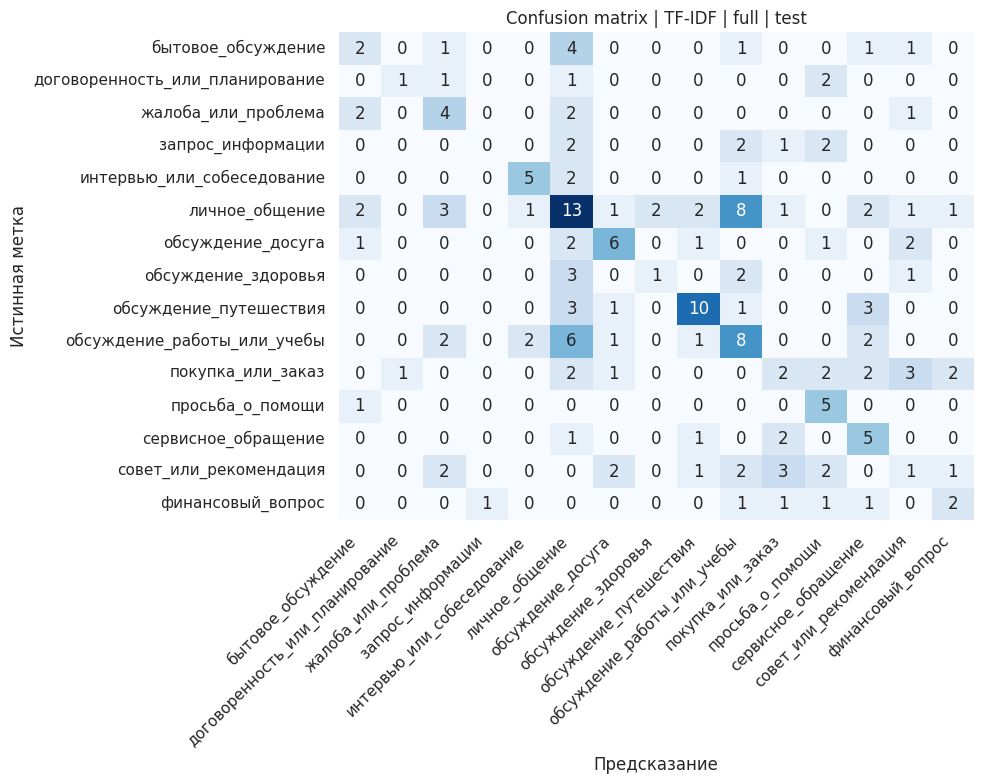


[Подвыборки по isambiguous | TF-IDF | full | test]
isambiguous == 0 (n=140): acc=0.3857, macro-F1=0.3500, weighted-F1=0.3649
isambiguous == 1 (n=47): acc=0.2340, macro-F1=0.1414, weighted-F1=0.2667

##### TF-IDF + LogReg | сценарий: clean #####
  C=0.5: val macro-F1 = 0.3597
  C=1.0: val macro-F1 = 0.3876
  C=2.0: val macro-F1 = 0.3270
  Лучший C = 1.0 (val macro-F1 = 0.3876)
=== TF-IDF | clean | val ===
accuracy:    0.4071
macro-F1:    0.3876
weighted-F1: 0.4051
                                 precision    recall  f1-score   support

             бытовое_обсуждение       0.24      0.50      0.32         8
договоренность_или_планирование       0.25      0.33      0.29         3
            жалоба_или_проблема       0.31      0.44      0.36         9
              запрос_информации       0.17      0.17      0.17         6
     интервью_или_собеседование       0.56      0.62      0.59         8
                 личное_общение       0.45      0.60      0.51        15
              обсуж

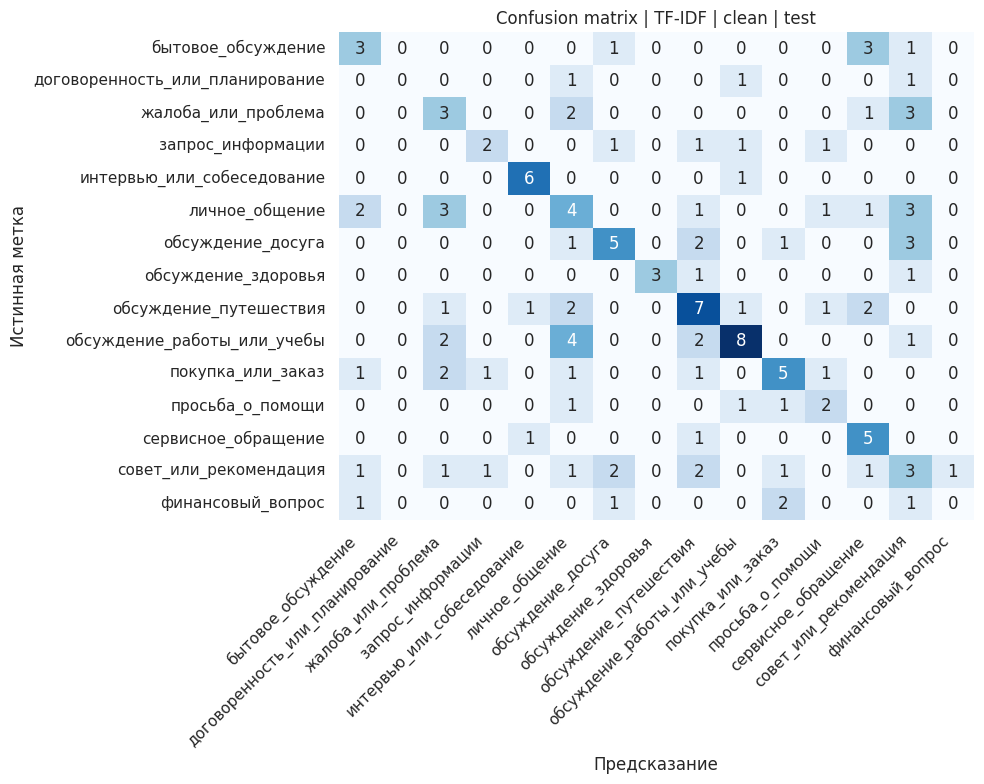


[Подвыборки по isambiguous | TF-IDF | clean | test]
isambiguous == 0 (n=140): acc=0.4000, macro-F1=0.3856, weighted-F1=0.3960
isambiguous == 1: подвыборка пуста, пропуск


In [20]:
def run_tfidf_scenario(df_scenario, splits, scenario_name, model_tag="tfidf_logreg"):
    """Полный прогон TF-IDF + LogReg на сценарии: train/val/test, метрики, confusion matrix.

    Сохраняет артефакты с фиксированными именами (см. save_baseline_artifacts).
    """
    print(f"\n##### TF-IDF + LogReg | сценарий: {scenario_name} #####")
    texts_train = df_scenario.loc[splits["train_idx"], "dialogue"].tolist()
    texts_val = df_scenario.loc[splits["val_idx"], "dialogue"].tolist()
    texts_test = df_scenario.loc[splits["test_idx"], "dialogue"].tolist()
    y_train = df_scenario.loc[splits["train_idx"], "primaryintent"].to_numpy()
    y_val = df_scenario.loc[splits["val_idx"], "primaryintent"].to_numpy()
    y_test = df_scenario.loc[splits["test_idx"], "primaryintent"].to_numpy()

    vectorizer, X_train, X_val, X_test = build_tfidf_features(
        texts_train, texts_val, texts_test
    )
    model, best_C = train_linear_baseline(X_train, y_train, X_val, y_val)

    labels_sorted = sorted(df_scenario["primaryintent"].unique().tolist())

    # --- VAL ---
    val_pred = model.predict(X_val)
    val_metrics = evaluate_predictions(
        y_val, val_pred, labels=labels_sorted,
        title=f"TF-IDF | {scenario_name} | val",
    )
    record_result(model_tag, scenario_name, "val", val_metrics)

    # --- TEST ---
    test_pred = model.predict(X_test)
    test_metrics = evaluate_predictions(
        y_test, test_pred, labels=labels_sorted,
        title=f"TF-IDF | {scenario_name} | test",
    )
    record_result(model_tag, scenario_name, "test", test_metrics)

    # --- Сохранение артефактов с фиксированными именами ---
    # Стабильные report/CM для test (имена под ВКР):
    save_baseline_artifacts(
        model_tag=model_tag,
        scenario=scenario_name,
        split="test",
        metrics=test_metrics,
        y_true=y_test,
        y_pred=test_pred,
        labels=labels_sorted,
        tables_dir=TABLES_DIR,
        figures_dir=FIGURES_DIR,
    )
    # Дополнительно — артефакты для val с явным _val (по тому же помощнику):
    save_baseline_artifacts(
        model_tag=model_tag,
        scenario=scenario_name,
        split="val",
        metrics=val_metrics,
        y_true=y_val,
        y_pred=val_pred,
        labels=labels_sorted,
        tables_dir=TABLES_DIR,
        figures_dir=FIGURES_DIR,
    )

    # Per-scenario стабильная таблица метрик (val + test).
    scenario_rows = [r for r in results_rows
                     if r["model"] == model_tag and r["scenario"] == scenario_name]
    save_scenario_metrics_csv(model_tag, scenario_name, scenario_rows, tables_dir=TABLES_DIR)

    # Отображение confusion matrix в выводе ноутбука (исторический интерфейс).
    plot_confusion_matrix(
        test_metrics["confusion_matrix"],
        labels=labels_sorted,
        title=f"Confusion matrix | TF-IDF | {scenario_name} | test",
        save_path=None,
    )

    print(f"\n[Подвыборки по isambiguous | TF-IDF | {scenario_name} | test]")
    evaluate_on_ambiguous_subsets(df_scenario, splits["test_idx"], y_test, test_pred)

    return {
        "vectorizer": vectorizer,
        "model": model,
        "best_C": best_C,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "labels": labels_sorted,
    }


tfidf_full = run_tfidf_scenario(df_full, splits_full, scenario_name="full")
tfidf_clean = run_tfidf_scenario(df_clean, splits_clean, scenario_name="clean")



##### Transformer (DeepPavlov/rubert-base-cased) | сценарий: full #####


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss
1,2.742188,2.718435
2,2.725461,2.707797
3,2.728360,2.706069
4,2.716847,2.706139
5,2.713628,2.705530


Map:   0%|          | 0/187 [00:00<?, ? examples/s]

=== Transformer | full | val ===
accuracy:    0.1979
macro-F1:    0.0220
weighted-F1: 0.0654
                                 precision    recall  f1-score   support

             бытовое_обсуждение       0.00      0.00      0.00        10
договоренность_или_планирование       0.00      0.00      0.00         5
            жалоба_или_проблема       0.00      0.00      0.00         9
              запрос_информации       0.00      0.00      0.00         7
     интервью_или_собеседование       0.00      0.00      0.00         7
                 личное_общение       0.20      1.00      0.33        37
              обсуждение_досуга       0.00      0.00      0.00        13
            обсуждение_здоровья       0.00      0.00      0.00         7
         обсуждение_путешествия       0.00      0.00      0.00        18
    обсуждение_работы_или_учебы       0.00      0.00      0.00        21
              покупка_или_заказ       0.00      0.00      0.00        15
               просьба_о_помощ

Map:   0%|          | 0/187 [00:00<?, ? examples/s]

=== Transformer | full | test ===
accuracy:    0.1979
macro-F1:    0.0220
weighted-F1: 0.0654
                                 precision    recall  f1-score   support

             бытовое_обсуждение       0.00      0.00      0.00        10
договоренность_или_планирование       0.00      0.00      0.00         5
            жалоба_или_проблема       0.00      0.00      0.00         9
              запрос_информации       0.00      0.00      0.00         7
     интервью_или_собеседование       0.00      0.00      0.00         8
                 личное_общение       0.20      1.00      0.33        37
              обсуждение_досуга       0.00      0.00      0.00        13
            обсуждение_здоровья       0.00      0.00      0.00         7
         обсуждение_путешествия       0.00      0.00      0.00        18
    обсуждение_работы_или_учебы       0.00      0.00      0.00        22
              покупка_или_заказ       0.00      0.00      0.00        15
               просьба_о_помо

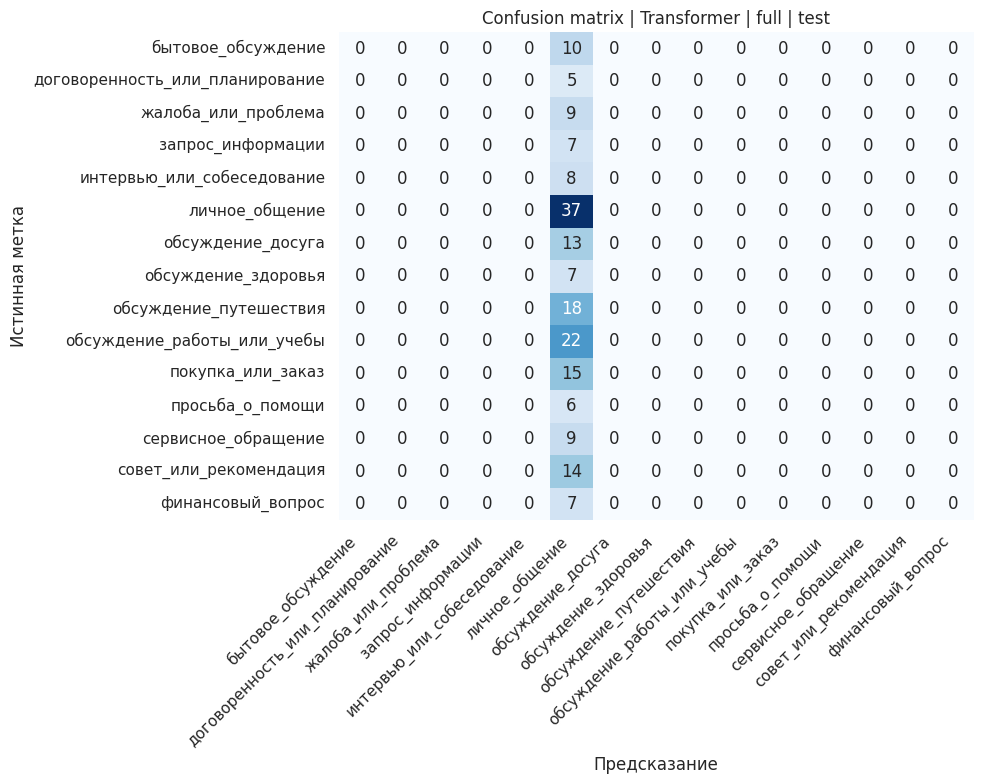


[Подвыборки по isambiguous | Transformer | full | test]
isambiguous == 0 (n=140): acc=0.1286, macro-F1=0.0152, weighted-F1=0.0293
isambiguous == 1 (n=47): acc=0.4043, macro-F1=0.0480, weighted-F1=0.2328

##### Transformer (DeepPavlov/rubert-base-cased) | сценарий: clean #####


Map:   0%|          | 0/651 [00:00<?, ? examples/s]

Map:   0%|          | 0/140 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

...

Epoch,Training Loss,Validation Loss
1,2.767527,2.682546
2,2.373785,2.264210
3,2.046812,2.100095
4,1.486883,2.101374
5,1.227757,2.111482


Map:   0%|          | 0/140 [00:00<?, ? examples/s]

=== Transformer | clean | val ===
accuracy:    0.4000
macro-F1:    0.3255
weighted-F1: 0.3656
                                 precision    recall  f1-score   support

             бытовое_обсуждение       0.25      0.25      0.25         8
договоренность_или_планирование       0.00      0.00      0.00         3
            жалоба_или_проблема       0.33      0.33      0.33         9
              запрос_информации       0.00      0.00      0.00         6
     интервью_или_собеседование       0.50      0.50      0.50         8
                 личное_общение       0.43      0.87      0.58        15
              обсуждение_досуга       0.50      0.75      0.60        12
            обсуждение_здоровья       0.25      0.20      0.22         5
         обсуждение_путешествия       0.64      0.60      0.62        15
    обсуждение_работы_или_учебы       0.31      0.29      0.30        17
              покупка_или_заказ       0.36      0.33      0.35        12
               просьба_о_помо

Map:   0%|          | 0/140 [00:00<?, ? examples/s]

=== Transformer | clean | test ===
accuracy:    0.4643
macro-F1:    0.4104
weighted-F1: 0.4325
                                 precision    recall  f1-score   support

             бытовое_обсуждение       0.47      0.88      0.61         8
договоренность_или_планирование       0.00      0.00      0.00         3
            жалоба_или_проблема       0.38      0.33      0.35         9
              запрос_информации       0.25      0.17      0.20         6
     интервью_или_собеседование       0.57      0.57      0.57         7
                 личное_общение       0.29      0.33      0.31        15
              обсуждение_досуга       0.45      0.83      0.59        12
            обсуждение_здоровья       0.80      0.80      0.80         5
         обсуждение_путешествия       0.53      0.67      0.59        15
    обсуждение_работы_или_учебы       0.80      0.47      0.59        17
              покупка_или_заказ       0.47      0.67      0.55        12
               просьба_о_пом

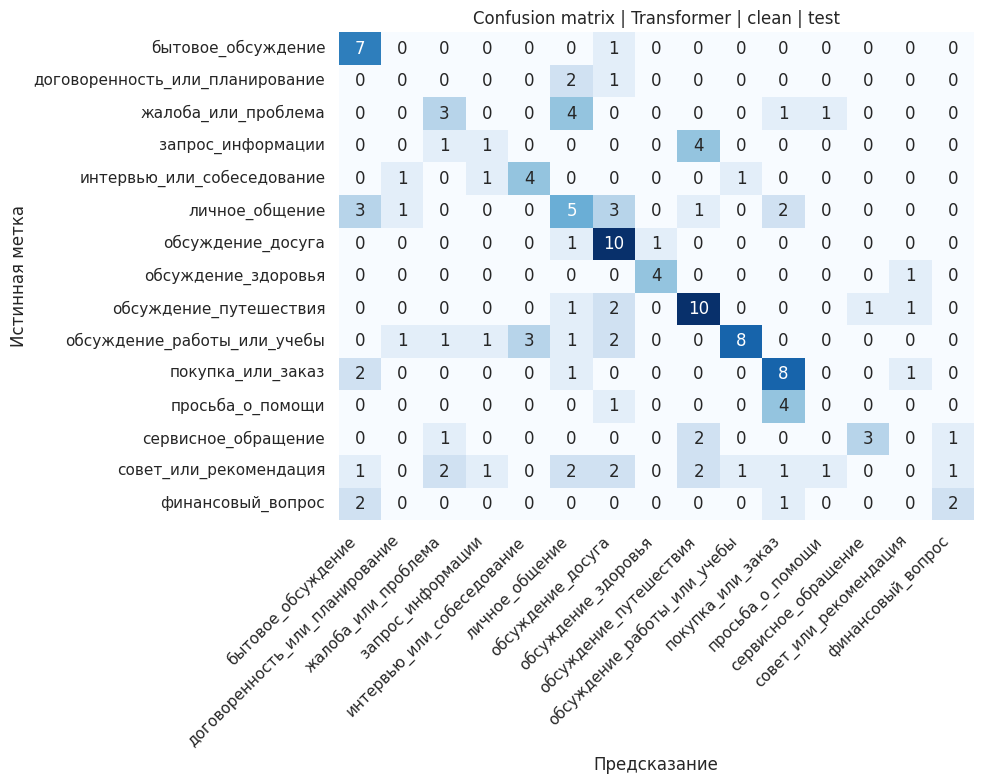


[Подвыборки по isambiguous | Transformer | clean | test]
isambiguous == 0 (n=140): acc=0.4643, macro-F1=0.4104, weighted-F1=0.4325
isambiguous == 1: подвыборка пуста, пропуск


In [21]:
def run_transformer_scenario(df_scenario, splits, scenario_name):
    """Полный прогон fine-tuning трансформера на сценарии. Запускается только при RUN_TRANSFORMER=True."""
    if not RUN_TRANSFORMER:
        print(
            f"[skip] Трансформер пропущен на сценарии {scenario_name}. "
            f"Установите RUN_TRANSFORMER=True, чтобы запустить fine-tuning."
        )
        return None

    print(f"\n##### Transformer ({MODEL_NAME}) | сценарий: {scenario_name} #####")
    data = prepare_transformer_data(df_scenario, splits)
    trainer, tokenizer = train_transformer_baseline(data)

    id2label = data["id2label"]
    labels_sorted = [id2label[i] for i in range(len(id2label))]

    val_pred_ids = transformer_predict(trainer, tokenizer, data["val"])
    val_true_ids = np.array(data["val"]["label"])
    val_pred = [id2label[i] for i in val_pred_ids]
    val_true = [id2label[i] for i in val_true_ids]
    val_metrics = evaluate_predictions(
        val_true, val_pred, labels=labels_sorted,
        title=f"Transformer | {scenario_name} | val",
    )
    record_result("transformer", scenario_name, "val", val_metrics)

    test_pred_ids = transformer_predict(trainer, tokenizer, data["test"])
    test_true_ids = np.array(data["test"]["label"])
    test_pred = [id2label[i] for i in test_pred_ids]
    test_true = [id2label[i] for i in test_true_ids]
    test_metrics = evaluate_predictions(
        test_true, test_pred, labels=labels_sorted,
        title=f"Transformer | {scenario_name} | test",
    )
    record_result("transformer", scenario_name, "test", test_metrics)

    plot_confusion_matrix(
        test_metrics["confusion_matrix"],
        labels=labels_sorted,
        title=f"Confusion matrix | Transformer | {scenario_name} | test",
        save_path=f"{FIGURES_DIR}/cm_transformer_{scenario_name}_test.png",
    )

    print(f"\n[Подвыборки по isambiguous | Transformer | {scenario_name} | test]")
    evaluate_on_ambiguous_subsets(df_scenario, splits["test_idx"], test_true, test_pred)

    return {
        "trainer": trainer,
        "tokenizer": tokenizer,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "labels": labels_sorted,
    }


# По умолчанию выполнение трансформера выключено (RUN_TRANSFORMER = False).
# Демонстрационный запуск на сценарии full; при желании можно вызвать для clean аналогично.
transformer_full = run_transformer_scenario(df_full, splits_full, scenario_name="full")
transformer_clean = run_transformer_scenario(df_clean, splits_clean, scenario_name="clean")

## Анализ результатов

Ниже собираем сводную таблицу метрик по всем запущенным моделям/сценариям/выборкам и сохраняем её в `results/tables/baseline_metrics.csv` на Google Drive. Помимо этой агрегированной таблицы, во время прогона TF-IDF baseline уже сохранены стабильные per-scenario файлы для ВКР:

- `results/tables/tfidf_logreg_full_metrics.csv`, `results/tables/tfidf_logreg_full_classification_report_test.csv`, `results/figures/tfidf_logreg_full_confusion_matrix_test.png`;
- `results/tables/tfidf_logreg_clean_metrics.csv`, `results/tables/tfidf_logreg_clean_classification_report_test.csv`, `results/figures/tfidf_logreg_clean_confusion_matrix_test.png`.

После прогона следует заполнить выводы по сравнению baseline между собой, а также по влиянию неоднозначных диалогов и дисбаланса классов.

In [22]:
results_df = pd.DataFrame(results_rows, columns=[
    "model", "scenario", "split", "accuracy", "macro_f1", "weighted_f1",
])
results_df = results_df.sort_values(["model", "scenario", "split"]).reset_index(drop=True)

try:
    os.makedirs(TABLES_DIR, exist_ok=True)
    save_path = f"{TABLES_DIR}/baseline_metrics.csv"
    results_df.to_csv(save_path, index=False)
    print(f"Таблица метрик сохранена: {save_path}")
except Exception as exc:
    print(f"Не удалось сохранить таблицу метрик (не Colab/нет Drive?): {exc}")

results_df

Таблица метрик сохранена: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/baseline_metrics.csv


,model,scenario,split,accuracy,macro_f1,weighted_f1
0,tfidf_logreg,clean,test,0.400000,0.385638,0.395991
1,tfidf_logreg,clean,val,0.407143,0.387571,0.405069
2,tfidf_logreg,full,test,0.347594,0.323913,0.331530
3,tfidf_logreg,full,val,0.368984,0.326480,0.367335
4,transformer,clean,test,0.464286,0.410417,0.432508
5,transformer,clean,val,0.400000,0.325539,0.365555
6,transformer,full,test,0.197861,0.022024,0.065365
7,transformer,full,val,0.197861,0.022024,0.065365


Выводы по baseline‑моделированию. В рамках данного ноутбука реализован и оценен базовый TF‑IDF + логистический классификатор для задачи многоклассовой классификации интента русскоязычного диалога. На полном наборе данных, включающем как однозначные, так и неоднозначные диалоги (сценарий full), модель достигает на тестовой выборке точности порядка 0.35 и macro‑F1 около 0.32–0.33, тогда как на «чистой» подвыборке без неоднозначных примеров (clean, isambiguous = 0) качество заметно выше: точность около 0.40 и macro‑F1 порядка 0.39. Это подтверждает, что диалоги, помеченные как неоднозначные, действительно представляют более сложный случай для автоматической классификации. Анализ per‑class метрик и матриц ошибок показывает, что при использовании class_weight='balanced' базовая модель уверенно предсказывает наиболее частые интенты, но практически не справляется с редкими классами и систематически путает часть семантически близких интентов между собой. Тем самым TF‑IDF‑baseline задаёт воспроизводимую отправную точку для сравнения с более сложными моделями (fine‑tuned трансформерами, контекстными и графовыми подходами) и одновременно наглядно демонстрирует ограничения линейных моделей в условиях сильного дисбаланса классов и наличия неоднозначных диалогов.